# 4.1 - Multi Model Comparison

## 1: Dependencies and Imports

In [1]:
# Instalar LightGBM directamente desde el notebook
%pip install lightgbm xgboost catboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Standard library
import os
import time
import warnings

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import BayesianRidge, LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_pinball_loss,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from xgboost.sklearn import XGBRegressor

## 2: Load Data

In [3]:
# Path
input_file_path = '../data/Filtered.pkl'

if os.path.exists(input_file_path):
    df = pd.read_pickle(input_file_path)
    rows, cols = df.shape
    print(f"Dataset successfully loaded: {rows} rows and {cols} columns.")
else:
    print(f"Error: File not found at {input_file_path}")

# Quick preview of the loaded data
display(df.head(3))

Dataset successfully loaded: 114567 rows and 16 columns.


,order_id,is_delayed,actual_delivery_days,estimated_delivery_margin_days,purchase_month,purchase_day_of_week,product_weight_g,product_volume_cm3,product_category_name_english,customer_zip_code_prefix,seller_zip_code_prefix,is_same_state,customer_state_num_pred,seller_state_num_pred,freight_value,price
0,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99
1,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99
2,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99


## 3: Data Preparation

In [4]:
# Define the continuous regression target
y = df['actual_delivery_days']

# Extract metadata columns to keep them safe for later plotting/comparisons
meta_columns = ['estimated_delivery_margin_days']
meta_df = df[meta_columns]

# Define features to be excluded from training (No Data Leakage)
drop_columns = [
    'order_id', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng', 
    'is_delayed', 'actual_delivery_days'
] + meta_columns

X = df.drop(columns=drop_columns, errors='ignore')

# Categorical Feature Definition
categorical_features = [
    'product_category_name_english', 
    'customer_state_num_pred', 
    'seller_state_num_pred',
    'purchase_month', 
    'purchase_day_of_week',
    'is_same_state'
]

for feature in categorical_features:
    if feature in X.columns:
        X[feature] = X[feature].astype('category')

print(f"Feature Selection Summary:")
print(f" - Predictor variables (X): {X.shape[1]}")
print(f" - Target variable (y): actual_delivery_days")
print(f" - Metadata saved (meta_df): {meta_df.shape[1]} columns")

Feature Selection Summary:
 - Predictor variables (X): 12
 - Target variable (y): actual_delivery_days
 - Metadata saved (meta_df): 1 columns


In [5]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114567 entries, 0 to 119142
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype   
---  ------                         --------------   -----   
 0   purchase_month                 114567 non-null  category
 1   purchase_day_of_week           114567 non-null  category
 2   product_weight_g               114567 non-null  float64 
 3   product_volume_cm3             114567 non-null  float64 
 4   product_category_name_english  114567 non-null  category
 5   customer_zip_code_prefix       114567 non-null  int64   
 6   seller_zip_code_prefix         114567 non-null  float64 
 7   is_same_state                  114567 non-null  category
 8   customer_state_num_pred        114567 non-null  category
 9   seller_state_num_pred          114567 non-null  category
 10  freight_value                  114567 non-null  float64 
 11  price                          114567 non-null  float64 
dtypes: category(6), float

In [6]:
# Initial split: Reserve 15% for the final Hold-out Test set
X_train_val, X_test, y_train_val, y_test, meta_train_val, meta_test = train_test_split(
    X, y, meta_df, test_size=0.15, random_state=42
)

# Second split: Partition the remaining 85% into Training and Validation sets
X_train, X_val, y_train, y_val, meta_train, meta_val = train_test_split(
    X_train_val, y_train_val, meta_train_val, test_size=0.15, random_state=42
)

print("Data partitioning complete:")
print(f" - Training Set:   {X_train.shape[0]} samples")
print(f" - Validation Set: {X_val.shape[0]} samples")
print(f" - Final Test Set: {X_test.shape[0]} samples")

Data partitioning complete:
 - Training Set:   82773 samples
 - Validation Set: 14608 samples
 - Final Test Set: 17186 samples


In [7]:
display(X_train)
display(y_train)

,purchase_month,purchase_day_of_week,product_weight_g,product_volume_cm3,product_category_name_english,customer_zip_code_prefix,seller_zip_code_prefix,is_same_state,customer_state_num_pred,seller_state_num_pred,freight_value,price
44544,11,3,1800.0,32560.0,garden_tools,89230,15025.0,0,23,25,17.64,49.00
1118,7,4,900.0,11400.0,health_beauty,19830,80310.0,0,25,17,36.90,364.00
41933,12,6,200.0,1584.0,musical_instruments,14540,88056.0,0,25,23,16.00,177.90
118565,3,4,200.0,1056.0,health_beauty,30140,2350.0,0,10,25,18.80,559.99
13756,7,4,2050.0,15312.0,small_appliances,16400,21210.0,0,25,18,21.22,103.99
...,...,...,...,...,...,...,...,...,...,...,...,...
113325,7,5,250.0,2560.0,bed_bath_table,72250,14940.0,0,6,25,18.23,11.99
54540,7,4,1650.0,45000.0,sports_leisure,20031,87504.0,0,18,17,16.86,59.90
104182,8,5,150.0,1904.0,telephony,1046,13070.0,0,25,23,7.44,24.99
48740,12,4,600.0,8400.0,cool_stuff,35420,89254.0,0,10,23,17.92,25.00


44544     20.0
1118       9.0
41933     16.0
118565    11.0
13756     13.0
          ... 
113325     5.0
54540     17.0
104182     3.0
48740     12.0
55966     12.0
Name: actual_delivery_days, Length: 82773, dtype: float64

## 4: Multi Model Definition

In [8]:
warnings.filterwarnings('ignore')

# Data Preparation: One-Hot Encoding for model compatibility
X_train_encoded = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)

In [9]:
# Feature Alignment to ensure consistent columns between sets
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1)
X_test_encoded = X_test_encoded.fillna(0)

In [10]:
# Regression Model Candidates
models = [
    ['LinearRegression', LinearRegression()],
    ['BayesianRidge', BayesianRidge()],
    ['HistGradientBoosting', HistGradientBoostingRegressor()],
    ['GradientBoosting', GradientBoostingRegressor(n_estimators=100)],
    ['LGBM', LGBMRegressor(verbosity=-1)],
    ['XGB', XGBRegressor(verbosity=0)],
    ['CatBoost', CatBoostRegressor(logging_level='Silent', allow_writing_files=False)]
]

model_performance = []

In [11]:
print("Starting model performance comparison.\n")

for name, model in models:
    print(f"Training: {name}...")
    metrics = {}
    
    if hasattr(model, 'random_state'):
        model.random_state = 42
        
    metrics["Name"] = name
    
    # Training phase
    start_time = time.time()
    model.fit(X_train_encoded, y_train)
    end_time = time.time()
    
    # Prediction phase
    y_pred = model.predict(X_test_encoded)
    
    # Performance metrics calculation
    metrics["Train_Time (s)"] = round(end_time - start_time, 2)
    metrics["Test_MAE"] = mean_absolute_error(y_test, y_pred)
    metrics["Test_RMSE"] = np.sqrt(mean_squared_error(y_test, y_pred))
    metrics["Test_R2"] = r2_score(y_test, y_pred)
    metrics["Test_Bias"] = np.mean(y_pred - y_test)
    
    model_performance.append(metrics)

Starting model performance comparison.

Training: LinearRegression...


Training: BayesianRidge...
Training: HistGradientBoosting...
Training: GradientBoosting...
Training: LGBM...
Training: XGB...
Training: CatBoost...


## 5: Multi Model Evaluation

In [12]:
# Baseline Metric Calculation: Olist Legacy Estimates
olist_estimates = meta_test['estimated_delivery_margin_days']

baseline_results = {
    "Name": "BAU (Olist Legacy)",
    "Train_Time (s)": 0.00, 
    "Test_MAE": mean_absolute_error(y_test, olist_estimates),
    "Test_RMSE": np.sqrt(mean_squared_error(y_test, olist_estimates)),
    "Test_R2": r2_score(y_test, olist_estimates),
    "Test_Bias": np.mean(olist_estimates - y_test)
}

# Append baseline and generate final summary
model_performance.append(baseline_results)
comparison_results = pd.DataFrame(model_performance).drop_duplicates(subset="Name", keep='last')
comparison_results = comparison_results.sort_values(by="Test_MAE")

print("Model Benchmarking Results (Ordered by MAE):")
display(comparison_results)

Model Benchmarking Results (Ordered by MAE):


,Name,Train_Time (s),Test_MAE,Test_RMSE,Test_R2,Test_Bias
5,XGB,0.41,4.566303,7.795493,0.337397,0.110887
6,CatBoost,1.97,4.570778,7.733346,0.347919,0.069735
2,HistGradientBoosting,3.37,4.628797,7.797875,0.336992,0.057984
4,LGBM,0.54,4.637336,7.811375,0.334694,0.063721
3,GradientBoosting,13.04,4.833021,8.054472,0.292640,0.050596
1,BayesianRidge,1.18,4.961536,8.177263,0.270908,0.060583
0,LinearRegression,0.60,4.962342,8.177510,0.270864,0.060644
7,BAU (Olist Legacy),0.00,12.918538,15.433248,-1.597055,11.444082


In [13]:
print("Benchmarking complete. Generating final performance summary.")
print("The darkest blue the better.")

# Aggregate results and ensure a unique index
performance_df = pd.DataFrame(model_performance).drop_duplicates(subset="Name", keep='last').set_index("Name")

# Isolate AI model indices for conditional formatting
ai_model_indices = performance_df.index
if "BAU (Olist Legacy)" in ai_model_indices:
    ai_model_indices = ai_model_indices.drop("BAU (Olist Legacy)")

# Apply uniform visual styling using blues
styled_results = performance_df.style.background_gradient(
    subset=(ai_model_indices, ['Test_MAE', 'Test_RMSE', 'Test_Bias', 'Train_Time (s)']), 
    cmap='Blues_r',
    low=0.4, 
    high=0.4
).background_gradient(
    subset=(ai_model_indices, ['Test_R2']), 
    cmap='Blues',
    low=0.4, 
    high=0.4
).format(precision=3)

display(styled_results)

Benchmarking complete. Generating final performance summary.
The darkest blue the better.


,Train_Time (s),Test_MAE,Test_RMSE,Test_R2,Test_Bias
Name,,,,,
LinearRegression,0.600,4.962,8.178,0.271,0.061
BayesianRidge,1.180,4.962,8.177,0.271,0.061
HistGradientBoosting,3.370,4.629,7.798,0.337,0.058
GradientBoosting,13.040,4.833,8.054,0.293,0.051
LGBM,0.540,4.637,7.811,0.335,0.064
XGB,0.410,4.566,7.795,0.337,0.111
CatBoost,1.970,4.571,7.733,0.348,0.070
BAU (Olist Legacy),0.000,12.919,15.433,-1.597,11.444


## 6: Winner Model Retrain and Evaluation

Generating performance curves for 7 models...


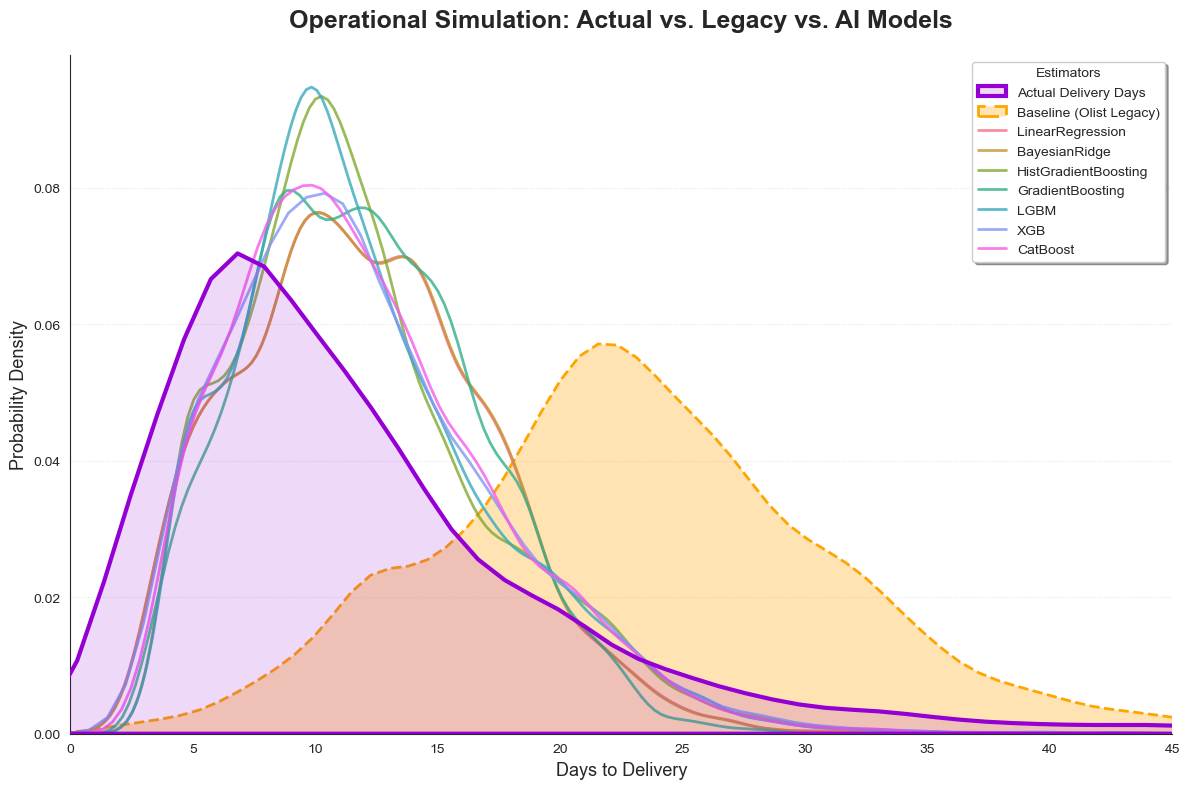


PRECISION ANALYSIS (RMSE - Lower is better):
 - Baseline (Legacy)      | RMSE: 15.43 days
--------------------------------------------------
 - LinearRegression       | RMSE: 8.18 days
 - BayesianRidge          | RMSE: 8.18 days
 - HistGradientBoosting   | RMSE: 7.80 days
 - GradientBoosting       | RMSE: 8.05 days
 - LGBM                   | RMSE: 7.81 days
 - XGB                    | RMSE: 7.80 days
 - CatBoost               | RMSE: 7.73 days


In [14]:
# Visualization Setup: Operational Simulation
sns.set_style("white")
plt.figure(figsize=(12, 8))

# Ground Truth: Actual delivery performance (KDE with fill)
sns.kdeplot(y_test, color='DarkViolet', label='Actual Delivery Days', linewidth=3, zorder=10, fill=True, alpha=0.15)

# Baseline: Olist Legacy estimations
olist_estimates = meta_test['estimated_delivery_margin_days']
sns.kdeplot(olist_estimates, color='Orange', label='Baseline (Olist Legacy)', linewidth=2, linestyle='--', fill=True, alpha=0.3)

# AI Models: Iterating through trained candidates using a palette
palette = sns.color_palette("husl", len(models))

print(f"Generating performance curves for {len(models)} models...")

for i, (name, model) in enumerate(models):
    y_pred = model.predict(X_test_encoded)
    sns.kdeplot(y_pred, label=f'{name}', alpha=0.8, linewidth=2, color=palette[i])

# Formatting and aesthetics
plt.title('Operational Simulation: Actual vs. Legacy vs. AI Models', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Days to Delivery', fontsize=13)
plt.ylabel('Probability Density', fontsize=13)
plt.xlim(0, 45)
plt.ylim(0, None)

# Moving the legend INSIDE the plot area to maximize horizontal space
plt.legend(title="Estimators", loc='upper right', fontsize=10, shadow=True, frameon=True)

plt.grid(axis='y', linestyle=':', alpha=0.5)
sns.despine() 

plt.tight_layout()
plt.show()

# Precision Analysis Summary (RMSE)
print("\nPRECISION ANALYSIS (RMSE - Lower is better):")
rmse_baseline = np.sqrt(mean_squared_error(y_test, olist_estimates))
print(f" - {'Baseline (Legacy)':<22} | RMSE: {rmse_baseline:.2f} days")
print("-" * 50)

for name, model in models:
    y_pred = model.predict(X_test_encoded)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f" - {name:<22} | RMSE: {rmse_val:.2f} days")